# Analyse des CV avec des boucles `for`

**Objectif :** transformer des JSON courts en un tableau lisible, calculer les
indicateurs en Python et expliquer les résultats.

Le modèle met les faits du texte en JSON. Les nombres de stages, de langages
et de projets sont calculés ici. Une ligne représente un candidat.

Exécuter les cellules dans l'ordre. Dépendances : `pandas`, `matplotlib`,
`ipykernel` (voir `extraction/requirements.txt`). **Ce notebook ne fait aucun
appel à une API.** Il utilise les JSON de `sorties/` ; si ce dossier est vide,
il utilise trois exemples saisis à la main et le signale ci-dessous.

## 1. Choisir les données

`Path` manipule les chemins ; `json` lit les fichiers ; `pandas` présente les
tableaux ; `matplotlib` trace les graphiques. Les petits outils importés depuis
`analyse.donnees` vérifient le format et uniformisent casse, accents et espaces.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Fonctionne depuis la racine du projet ou un de ses sous-dossiers.
reperes = [Path.cwd(), *Path.cwd().parents,
           Path.cwd() / "Project_3_Matthieu_Clement_Henry_Ethan_Ilyes"]
RACINE = next((p for p in reperes if (p / "prompt.md").is_file()
               and (p / "datas_extract").is_dir()), None)
if RACINE is None:
    raise FileNotFoundError("Ouvrir le notebook depuis le dossier du projet.")
sys.path.insert(0, str(RACINE))
from analyse.donnees import valide_cv, mention_standard, valeurs_uniques

# On peut remplacer cette valeur par un autre dossier de JSON courts.
DOSSIER = RACINE / "sorties"
MODE_EXEMPLES = False
if not list(DOSSIER.glob("*.json")):
    DOSSIER = RACINE / "analyse" / "exemples"
    MODE_EXEMPLES = True
ETIQUETTE = "EXEMPLES SAISIS À LA MAIN — 3 CV de test" if MODE_EXEMPLES else "JSON du dossier sorties"
print(ETIQUETTE)
print("Dossier :", DOSSIER)

Matplotlib is building the font cache; this may take a moment.


EXEMPLES SAISIS À LA MAIN — 3 CV de test
Dossier : /Users/clementforestier/Documents/GitHub/Project_3_Matthieu_Clement_Henry_Ethan_Ilyes/analyse/exemples


## 2. Lire chaque JSON avec une boucle

À chaque tour de la boucle, `chemin` désigne un fichier et `cv` son dictionnaire
Python. `append` ajoute ce candidat à la liste. On arrête l'analyse en cas de
JSON invalide ou de doublon : ignorer silencieusement un candidat fausserait
l'effectif. Les anciennes sorties avec `donnees_normalisees` doivent être
régénérées avec le nouveau prompt.

In [2]:
candidats = []
identifiants = set()
fichiers_sources = set()
for chemin in sorted(DOSSIER.glob("*.json")):
    cv = json.loads(chemin.read_text(encoding="utf-8"))
    erreurs = valide_cv(cv)
    if erreurs:
        raise ValueError(f"{chemin.name} : {'; '.join(erreurs)}")
    identifiant = cv["meta"]["id_candidat"]
    source = cv["meta"]["fichier_source"]
    if identifiant in identifiants or source in fichiers_sources:
        raise ValueError(f"Candidat en double : {identifiant}")
    identifiants.add(identifiant)
    fichiers_sources.add(source)
    candidats.append(cv)

if not candidats:
    raise ValueError("Aucun JSON à analyser.")
print(f"{len(candidats)} candidats chargés — {ETIQUETTE}")
# Exemple de contenu court, sans afficher tout le JSON :
display(candidats[0]["competences"])

3 candidats chargés — EXEMPLES SAISIS À LA MAIN — 3 CV de test


{'langages': ['Python', 'SQL'],
 'outils': ['pandas', 'matplotlib', 'Power BI', 'Excel', 'Git', 'GitHub'],
 'projets': ['StatsLigue1 : analyse de données du championnat de football ; scraping de 5 saisons, visualisations et modèle de prédiction ; environ 40 étoiles sur GitHub'],
 'certifications': []}

## 3. Calculer les indicateurs en Python

- La boucle extérieure parcourt les candidats.
- Les boucles intérieures parcourent leurs compétences et expériences.
- `len` compte les éléments et `+= 1` incrémente un compteur.
- `valeurs_uniques` évite de compter deux fois « Python » et « python ».
- `mention_standard` regroupe notamment « TB » et « Très Bien ».

**Zéro et valeur inconnue ont des sens différents.** Une liste vide dans une
rubrique lisible donne zéro élément **mentionné dans le CV**. Une rubrique
illisible donne `None`, affiché `NaN` dans le tableau et exclu des moyennes.
Si une expérience n'a pas de type identifiable, son existence reste comptée,
mais le nombre de stages et de jobs étudiants est laissé inconnu.

In [3]:
lignes, codes = [], []
for cv in candidats:
    illisibles = cv["rubriques_illisibles"]
    ligne = {"id_candidat": cv["meta"]["id_candidat"], "fichier_source": cv["meta"]["fichier_source"]}
    ligne["mention_bac"] = None if "formation" in illisibles else mention_standard(cv["formation"]["mention_bac"])
    ligne["nb_specialites"] = None if "formation" in illisibles else len(valeurs_uniques(cv["formation"]["specialites"]))
    for champ in ["langages", "outils", "projets", "certifications"]:
        valeurs = valeurs_uniques(cv["competences"][champ])
        ligne[f"nb_{champ}"] = None if "competences" in illisibles else len(valeurs)
        if champ in ["langages", "outils"] and "competences" not in illisibles:
            for valeur in valeurs:
                codes.append({"id_candidat": ligne["id_candidat"], "champ": champ, "code": valeur})
    ligne["nb_experiences"] = None if "experiences" in illisibles else len(cv["experiences"])
    nb_stages, nb_jobs = 0, 0
    types_connus = True
    for experience in cv["experiences"]:
        if experience["type"] is None:
            types_connus = False
        if experience["type"] == "stage":
            nb_stages += 1
        if experience["type"] == "job_etudiant":
            nb_jobs += 1
    ligne["nb_stages"] = nb_stages if types_connus and "experiences" not in illisibles else None
    ligne["nb_jobs_etudiants"] = nb_jobs if types_connus and "experiences" not in illisibles else None
    ligne["nb_langues"] = None if "langues" in illisibles else len(valeurs_uniques([x["langue"] for x in cv["langues"]]))
    ligne["nb_engagements"] = None if "engagements" in illisibles else len(cv["engagements"])
    ligne["nb_sejours"] = None if "international" in illisibles else len(cv["international"])
    ligne["rubriques_illisibles"] = ", ".join(illisibles)
    lignes.append(ligne)

df = pd.DataFrame(lignes)
df_codes = pd.DataFrame(codes, columns=["id_candidat", "champ", "code"])
print(ETIQUETTE)
display(df[["id_candidat", "mention_bac", "nb_langages", "nb_projets", "nb_experiences", "nb_stages", "nb_engagements", "nb_sejours"]])

EXEMPLES SAISIS À LA MAIN — 3 CV de test


,id_candidat,mention_bac,nb_langages,nb_projets,nb_experiences,nb_stages,nb_engagements,nb_sejours
0,01_lea_vasseur,tres bien,2,1,1,1,2,1
1,04_hugo_lefebvre,bien,0,0,2,1,2,0
2,10_kevin_dubreuil,sans mention,0,0,0,0,0,0


## 4. Compter les langages avec deux boucles

On compte le nombre de candidats qui mentionnent chaque langage, une seule
fois par candidat. Le dénominateur des pourcentages est le nombre de CV dont
la rubrique compétences est exploitable. Les candidats sans langage mentionné
font partie de cette base ; les rubriques illisibles en sont exclues.

In [4]:
effectifs_langages = {}
base_competences = 0
for cv in candidats:
    if "competences" in cv["rubriques_illisibles"]:
        continue
    base_competences += 1
    for langage in valeurs_uniques(cv["competences"]["langages"]):
        if langage not in effectifs_langages:
            effectifs_langages[langage] = 0
        effectifs_langages[langage] += 1

lignes_langages = []
for langage, effectif in effectifs_langages.items():
    lignes_langages.append({"langage": langage, "candidats": effectif,
                           "pourcentage": 100 * effectif / base_competences})
frequences = pd.DataFrame(lignes_langages, columns=["langage", "candidats", "pourcentage"])
frequences = frequences.sort_values("candidats", ascending=False)
print(f"Compétences exploitables : {base_competences}/{len(candidats)} CV")
display(frequences)

Compétences exploitables : 3/3 CV


,langage,candidats,pourcentage
0,python,1,33.333333
1,sql,1,33.333333


## 5. Résumer les stages sans transformer les inconnus en zéro

`dropna()` retire seulement les valeurs inconnues. La moyenne compte tous les
CV exploitables, y compris ceux sans stage mentionné. On conserve également
le nombre de CV exclus pour interpréter le résultat.

In [5]:
stages_connus = df["nb_stages"].dropna()
avec_stage = 0
somme_stages = 0
for nombre in stages_connus:
    somme_stages += nombre
    if nombre > 0:
        avec_stage += 1

if len(stages_connus) == 0:
    print("Aucun nombre de stages exploitable.")
else:
    print(f"Au moins un stage mentionné : {avec_stage}/{len(stages_connus)} CV ({100 * avec_stage / len(stages_connus):.1f} %)")
    print(f"Nombre moyen de stages mentionnés : {somme_stages / len(stages_connus):.2f}")
print(f"CV exclus de ce calcul : {len(df) - len(stages_connus)}")

Au moins un stage mentionné : 2/3 CV (66.7 %)
Nombre moyen de stages mentionnés : 0.67
CV exclus de ce calcul : 0


## 6. Visualiser les résultats

Ces graphiques décrivent le lot chargé. En mode exemples, il ne s'agit que de
**trois profils choisis pour la démonstration**, pas de toute la promotion.
Les mentions absentes ou illisibles sont affichées comme non renseignées.

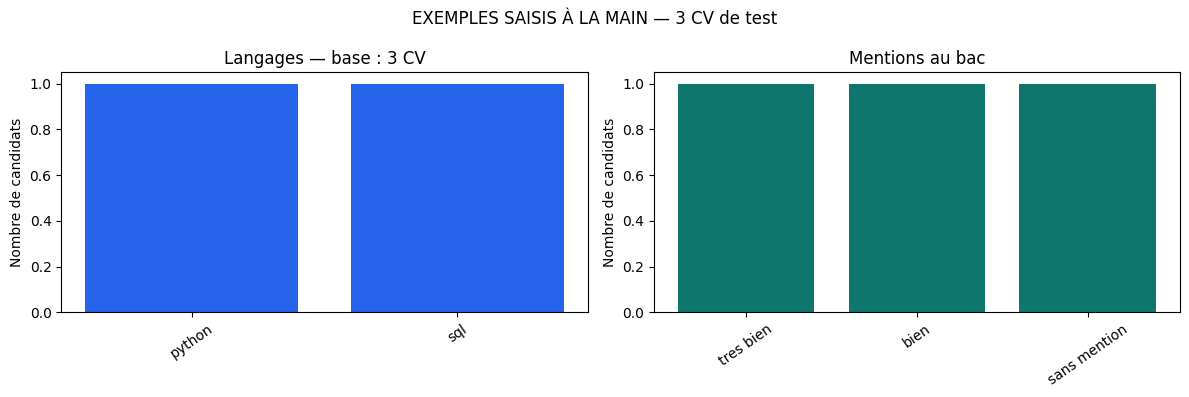

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if frequences.empty:
    axes[0].text(0.5, 0.5, "Aucun langage exploitable", ha="center", va="center")
    axes[0].set_axis_off()
else:
    axes[0].bar(frequences["langage"], frequences["candidats"], color="#2563eb")
    axes[0].set_ylabel("Nombre de candidats")
    axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title(f"Langages — base : {base_competences} CV")
mentions = df["mention_bac"].fillna("non renseignée / illisible").value_counts()
axes[1].bar(mentions.index, mentions.values, color="#0f766e")
axes[1].set_title("Mentions au bac")
axes[1].set_ylabel("Nombre de candidats")
axes[1].tick_params(axis="x", rotation=35)
fig.suptitle(ETIQUETTE)
fig.tight_layout()
plt.show()

## 7. Consulter les résultats scolaires avec leur contexte

Une moyenne de terminale, une moyenne de maths et une note au bac décrivent
des choses différentes. On les met dans un tableau séparé en conservant leur
intitulé ; on ne calcule pas une moyenne qui les mélangerait. Une échelle
inconnue n'est pas convertie en note sur 20.

In [7]:
resultats = []
for cv in candidats:
    if "formation" in cv["rubriques_illisibles"]:
        continue
    for resultat in cv["formation"]["resultats"]:
        resultats.append({"id_candidat": cv["meta"]["id_candidat"],
                          "intitule": resultat["intitule"],
                          "note_sur_20": resultat["note_sur_20"]})
df_resultats = pd.DataFrame(resultats, columns=["id_candidat", "intitule", "note_sur_20"])
display(df_resultats)

,id_candidat,intitule,note_sur_20
0,01_lea_vasseur,Moyenne générale de Terminale,17.4
1,01_lea_vasseur,Moyenne en mathématiques,18.2
2,04_hugo_lefebvre,Moyenne générale,14.8
3,10_kevin_dubreuil,Moyenne générale,12.1


## 8. Comparer aux notes de référence

Ces notes sont fournies par le projet. Elles ne sont ni prédites par ce
notebook ni envoyées au modèle. La jointure se fait sur le nom du PDF.
La comparaison est descriptive : trois exemples ne permettent pas de mesurer
la qualité d'un système de notation ni de conclure à une relation de cause à effet.

In [8]:
chemin_notes = RACINE / "cv-test" / "notes-reference.csv"
if chemin_notes.exists():
    notes = pd.read_csv(chemin_notes, sep=";")
    comparaison = df.merge(notes[["fichier", "total_sur20"]],
                          left_on="fichier_source", right_on="fichier", how="left",
                          validate="one_to_one")
    print(f"{comparaison['total_sur20'].notna().sum()}/{len(df)} CV associés à une note de référence")
    display(comparaison[["id_candidat", "mention_bac", "nb_langages", "nb_stages", "total_sur20"]])
else:
    print("Fichier de notes de référence absent : comparaison ignorée.")

3/3 CV associés à une note de référence


,id_candidat,mention_bac,nb_langages,nb_stages,total_sur20
0,01_lea_vasseur,tres bien,2,1,19.0
1,04_hugo_lefebvre,bien,0,1,11.0
2,10_kevin_dubreuil,sans mention,0,0,4.0


## 9. Exporter le tableau

Les exemples sont exportés dans `analyse/demo/` pour garder leur provenance
visible. Avec des réponses dans `sorties/`, les exports vont dans `analyse/`.
Ces fichiers sont régénérables et ignorés par Git.

In [9]:
DOSSIER_EXPORT = RACINE / "analyse" / "demo" if MODE_EXEMPLES else RACINE / "analyse"
DOSSIER_EXPORT.mkdir(parents=True, exist_ok=True)
df.to_csv(DOSSIER_EXPORT / "candidats.csv", index=False)
df_codes.to_csv(DOSSIER_EXPORT / "codes.csv", index=False)
print("Exports :", DOSSIER_EXPORT / "candidats.csv", "et", DOSSIER_EXPORT / "codes.csv")

# Vérifie que la version en script donne les mêmes résultats que nos boucles.
from analyse.agrege import construit_tables
table_script, codes_script = construit_tables(candidats)
pd.testing.assert_frame_equal(df, table_script)
pd.testing.assert_frame_equal(df_codes, codes_script)
print("Les calculs du notebook et du script sont cohérents.")

Exports : /Users/clementforestier/Documents/GitHub/Project_3_Matthieu_Clement_Henry_Ethan_Ilyes/analyse/demo/candidats.csv et /Users/clementforestier/Documents/GitHub/Project_3_Matthieu_Clement_Henry_Ethan_Ilyes/analyse/demo/codes.csv
Les calculs du notebook et du script sont cohérents.


## 10. Interprétation à présenter

Pour chaque résultat, préciser le lot, l'effectif exploitable et les exclusions.
Exemple : « Parmi les CV dont les expériences sont lisibles et de type connu,
X sur N mentionnent au moins un stage. »

- Une compétence **mentionnée** n'est pas une compétence évaluée.
- Une absence de mention ne prouve pas que le candidat ne possède pas l'expérience.
- Les durées restent du texte : leur conversion demande des règles explicites.
- Pour vérifier les informations, revenir au `.txt` de `datas_extract/` puis au PDF.
- Une fois les JSON des 11 CV générés, relancer toutes les cellules et rédiger
  les conclusions sur ce nouveau lot ; les exemples ne mesurent pas la qualité du LLM.